# SPY Direction Model Visualization Report

This notebook is the interactive report for the project. It reads the generated pipeline outputs, summarizes the model/backtest results, regenerates the visualization PNGs, and displays them inline.

Run these first from the repository root if the CSVs do not exist:

```bash
python3 src/ml_pipeline.py
python3 src/model_backtest.py
```

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_DIR = REPO_ROOT / "data"
FIGURES_DIR = DATA_DIR / "figures"

from src.visualize import create_all_visualizations

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.6f}".format)

REPO_ROOT

PosixPath('/Users/felixtanwira/Documents/GitHub/stock-return-predictor')

## Load Generated Outputs

In [2]:
required_files = {
    "test_metrics": DATA_DIR / "ml_test_metrics.csv",
    "test_predictions": DATA_DIR / "ml_test_predictions.csv",
    "strategy_backtest": DATA_DIR / "ml_strategy_backtest.csv",
    "strategy_metrics": DATA_DIR / "ml_strategy_metrics.csv",
    "monte_carlo_comparison": DATA_DIR / "ml_monte_carlo_comparison.csv",
    "monte_carlo_samples": DATA_DIR / "ml_monte_carlo_samples.csv",
    "feature_correlations": DATA_DIR / "train_feature_correlations.csv",
    "supervised_dataset": DATA_DIR / "ml_supervised_dataset.csv",
}

missing = [str(path) for path in required_files.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing generated output files. Run `python3 src/ml_pipeline.py` and "
        "`python3 src/model_backtest.py` from the repository root first. Missing: "
        + ", ".join(missing)
    )

test_metrics = pd.read_csv(required_files["test_metrics"])
test_predictions = pd.read_csv(required_files["test_predictions"], parse_dates=["feature_timestamp", "target_timestamp"])
strategy_backtest = pd.read_csv(required_files["strategy_backtest"], parse_dates=["Date"])
strategy_metrics = pd.read_csv(required_files["strategy_metrics"])
monte_carlo_comparison = pd.read_csv(required_files["monte_carlo_comparison"])
monte_carlo_samples = pd.read_csv(required_files["monte_carlo_samples"])
feature_correlations = pd.read_csv(required_files["feature_correlations"])

print("Loaded generated outputs from:", DATA_DIR)

Loaded generated outputs from: /Users/felixtanwira/Documents/GitHub/stock-return-predictor/data


## Model Classification Summary

In [3]:
classification_fields = [
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "log_loss",
    "n_train",
    "n_test",
    "train_fraction",
    "test_fraction",
    "train_start_target_timestamp",
    "train_end_target_timestamp",
    "test_start_target_timestamp",
    "test_end_target_timestamp",
]

display(test_metrics[classification_fields].T.rename(columns={0: "value"}))

,value
accuracy,0.507246
balanced_accuracy,0.490152
roc_auc,0.476389
log_loss,0.711926
n_train,2756
n_test,690
train_fraction,0.799768
test_fraction,0.200232
train_start_target_timestamp,2010-10-19
train_end_target_timestamp,2021-09-29


## Strategy And Monte Carlo Summary

In [4]:
strategy_fields = [
    "strategy_total_return",
    "strategy_annualized_return",
    "strategy_sharpe",
    "strategy_max_drawdown",
    "buy_and_hold_total_return",
    "buy_and_hold_annualized_return",
    "buy_and_hold_sharpe",
    "buy_and_hold_max_drawdown",
    "excess_total_return",
    "excess_sharpe",
    "total_transaction_cost",
    "n_trade_days",
    "average_position",
]

display(strategy_metrics[strategy_fields].T.rename(columns={0: "value"}))
display(monte_carlo_comparison.T.rename(columns={0: "value"}))

,value
strategy_total_return,0.271661
strategy_annualized_return,0.091737
strategy_sharpe,0.601233
strategy_max_drawdown,-0.228879
buy_and_hold_total_return,0.305101
buy_and_hold_annualized_return,0.102136
buy_and_hold_sharpe,0.636348
buy_and_hold_max_drawdown,-0.244964
excess_total_return,-0.033440
excess_sharpe,-0.035116


,value
n_simulations,10000.000000
n_test_days,690.000000
seed,42.000000
actual_strategy_total_return,0.271661
actual_buy_and_hold_total_return,0.305101
actual_excess_total_return,-0.033440
strategy_beats_buy_and_hold_total_return_probability,0.386400
strategy_beats_buy_and_hold_sharpe_probability,0.425400
excess_total_return_p05,-0.246154
excess_total_return_p50,-0.030598


## Most Correlated Training Features

In [5]:
display(feature_correlations.head(20))

,feature_a,feature_b,correlation,abs_correlation,n_train,train_start_target_timestamp,train_end_target_timestamp
0,return_5d,sma_10d_ratio,0.916343,0.916343,2756,2010-10-19,2021-09-29
1,realized_vol_5d,realized_vol_10d,0.908710,0.908710,2756,2010-10-19,2021-09-29
2,return_10d,sma_20d_ratio,0.907937,0.907937,2756,2010-10-19,2021-09-29
3,realized_vol_10d,realized_vol_21d,0.904188,0.904188,2756,2010-10-19,2021-09-29
4,sma_20d_ratio,sma_5d_20d_spread,0.892868,0.892868,2756,2010-10-19,2021-09-29
5,return_2d,sma_5d_ratio,0.891164,0.891164,2756,2010-10-19,2021-09-29
6,sma_10d_ratio,sma_20d_ratio,0.873453,0.873453,2756,2010-10-19,2021-09-29
7,volume_zscore_21d,volume_zscore_63d,0.868471,0.868471,2756,2010-10-19,2021-09-29
8,sma_5d_ratio,sma_10d_ratio,0.858390,0.858390,2756,2010-10-19,2021-09-29
9,sma_50d_ratio,drawdown_21d,0.855696,0.855696,2756,2010-10-19,2021-09-29


## Generate And Display Charts

equity_curves.png


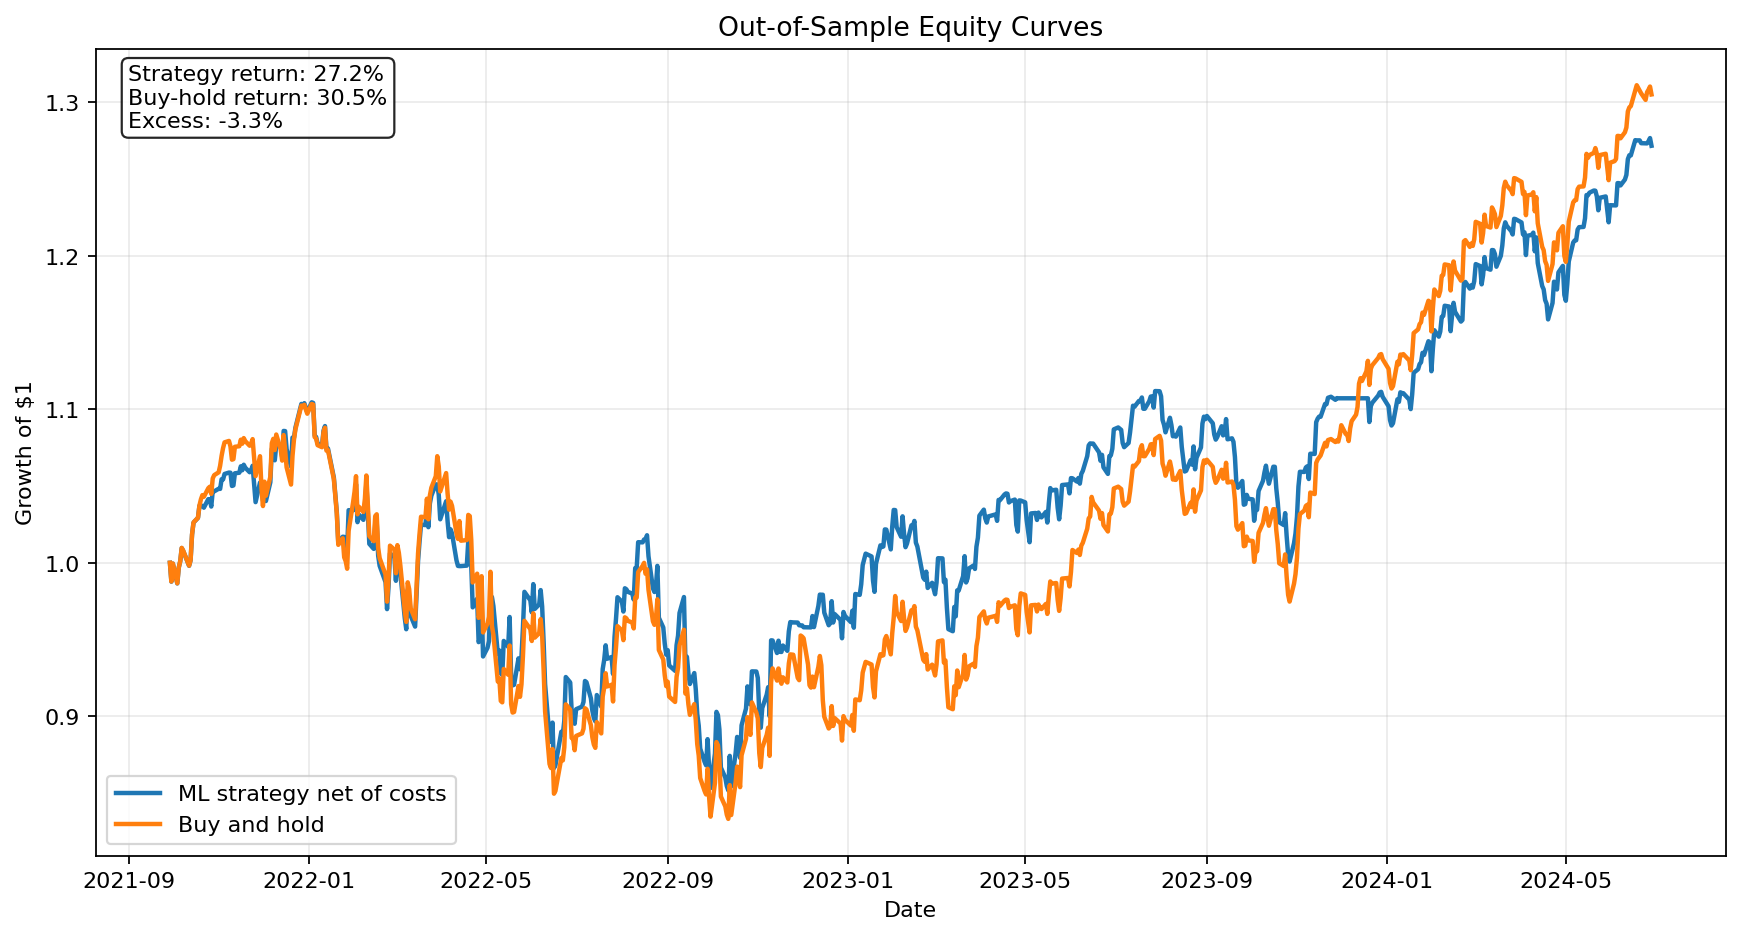

drawdowns.png


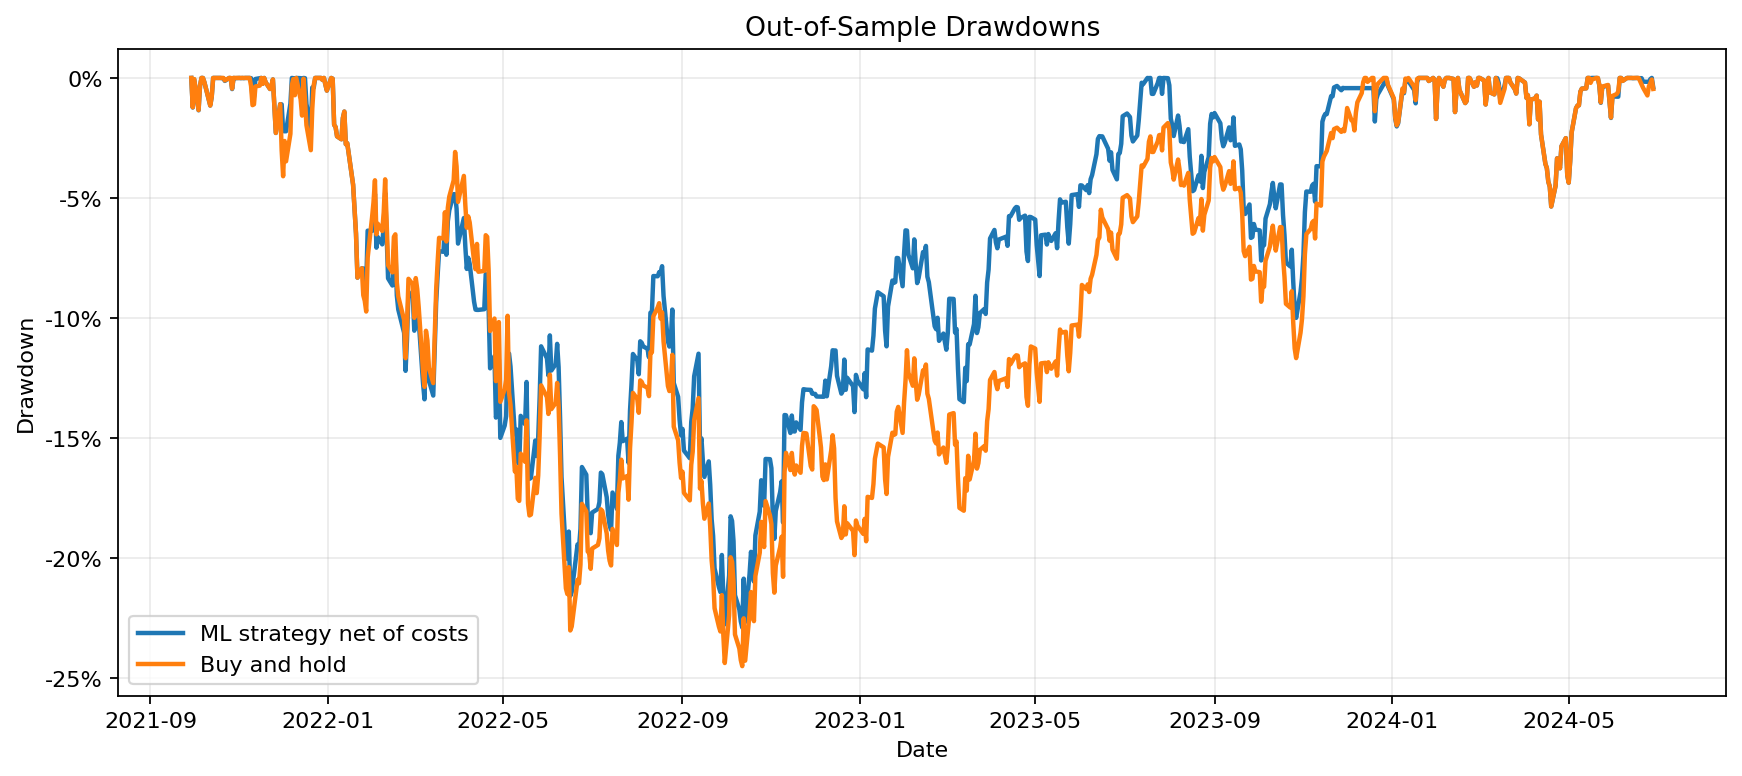

prediction_probabilities.png


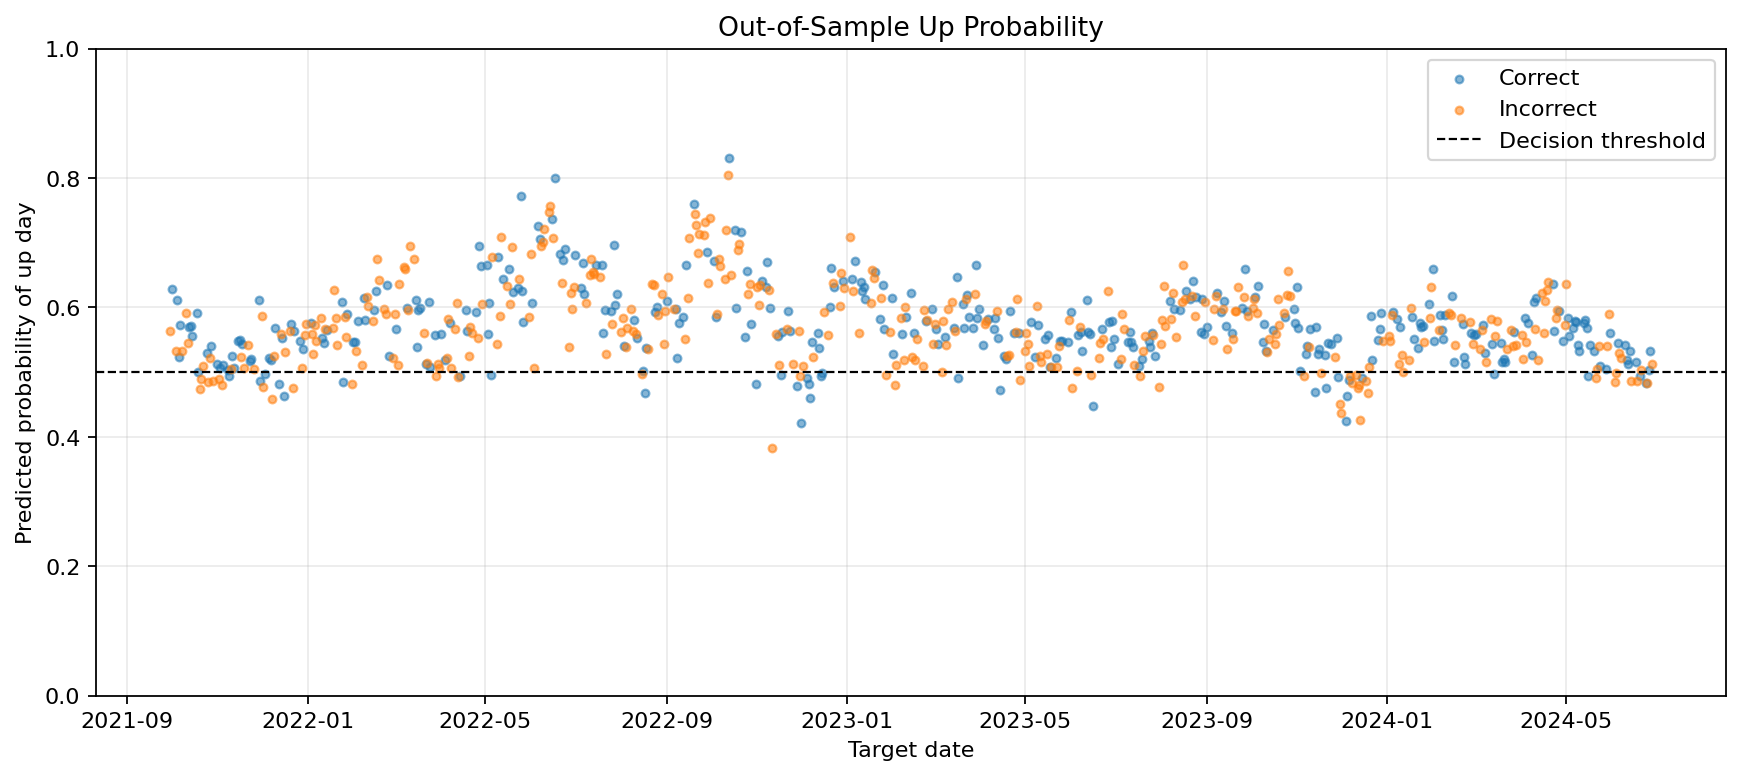

confusion_matrix.png


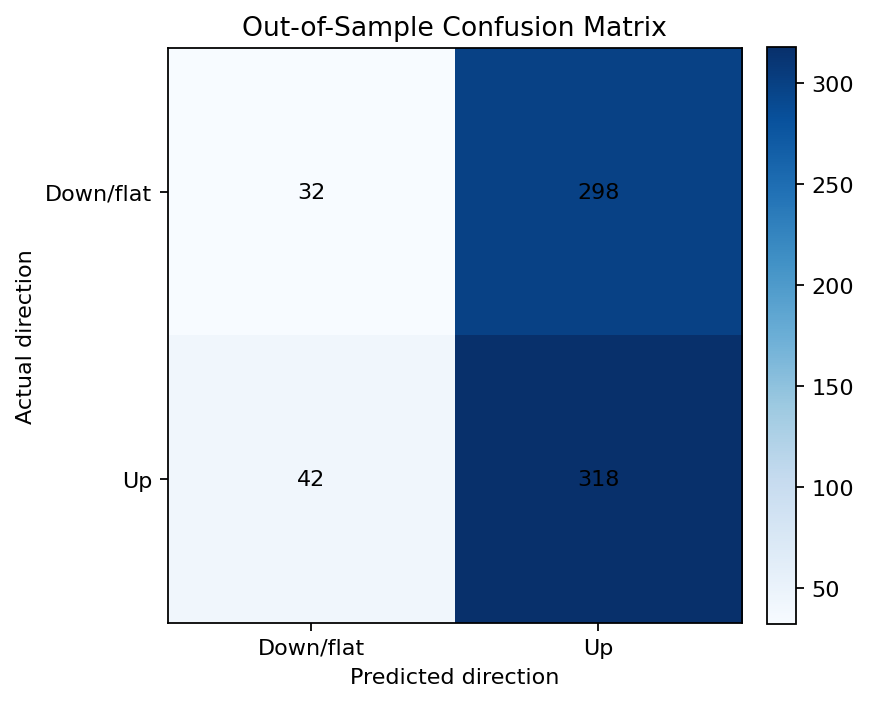

train_feature_correlation_heatmap.png


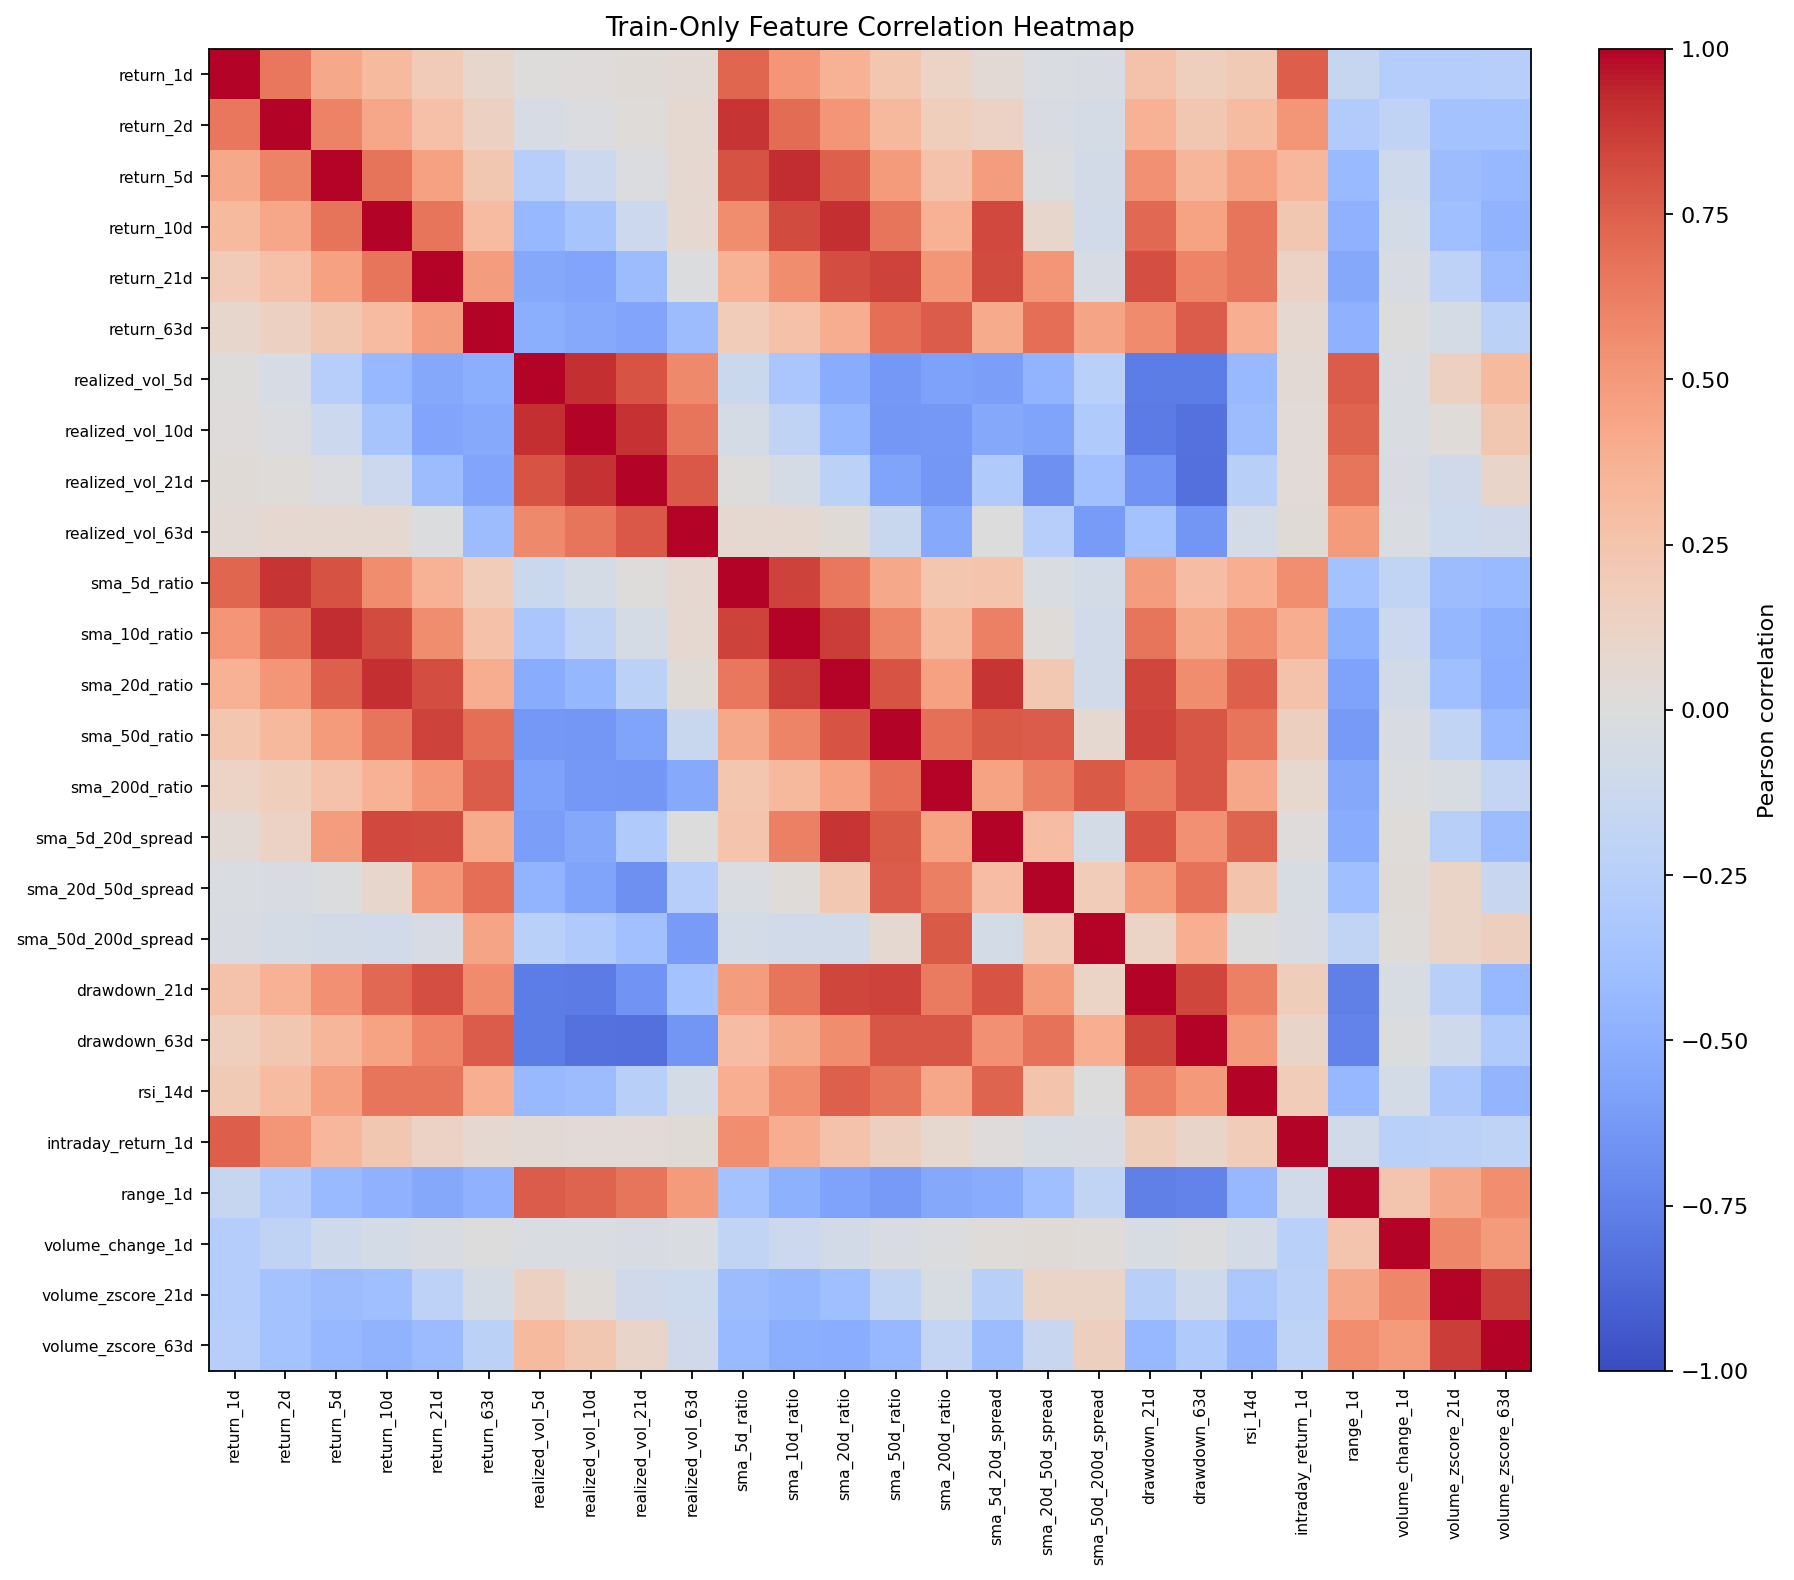

monte_carlo_excess_return.png


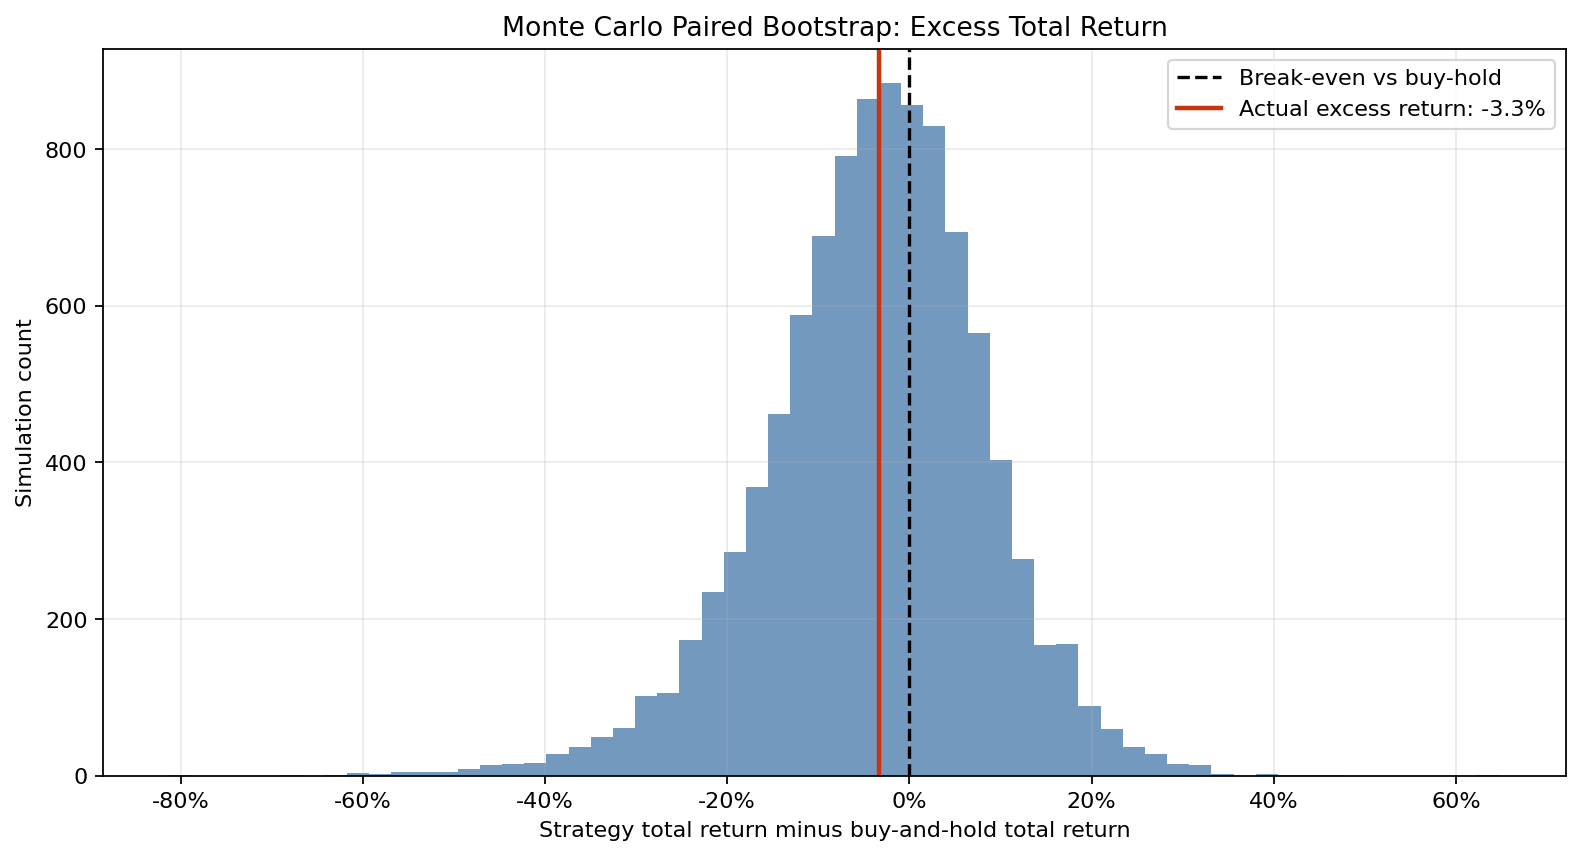

In [6]:
figure_paths = create_all_visualizations()
for path in figure_paths:
    print(path.name)
    display(Image(filename=str(path)))